<a href="https://colab.research.google.com/github/simjonghyeon04/-/blob/main/%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC%20%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sales Shape: (121253, 15)
Customer Shape: (18485, 7)
Product Shape: (397, 9)

Merged Shape: (121253, 39)

Missing Values Before:
Color                      34144
ShipDateKey                 2113
ResellerKey                    0
CustomerKey                    0
ProductKey                     0
OrderDateKey                   0
SalesOrderLineKey              0
DueDateKey                     0
SalesTerritoryKey              0
Unit Price                     0
Order Quantity                 0
Unit Price Discount Pct        0
Product Standard Cost          0
Total Product Cost             0
Extended Amount                0
Customer ID                    0
Customer                       0
City                           0
State-Province                 0
Country-Region                 0
dtype: int64

Shape After Cleaning: (85819, 39)

Shape After Outlier Removal: (81979, 39)

Descriptive Statistics
       SalesOrderLineKey   ResellerKey   CustomerKey    ProductKey  \
count       8.197900e+04  8

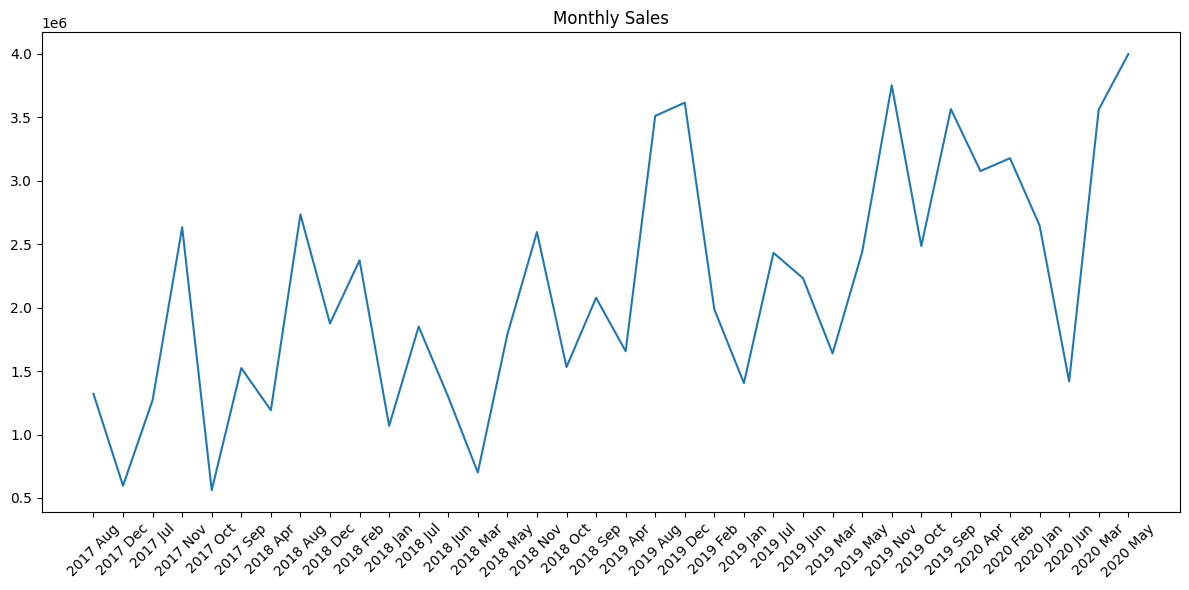


New Features Added:
        Date  Sale Year  Sale Quarter  Sale Month  Sale Dayofweek
0 2017-07-02       2017             3           7               6
2 2017-07-02       2017             3           7               6
3 2017-07-02       2017             3           7               6
4 2017-07-02       2017             3           7               6
5 2017-07-02       2017             3           7               6


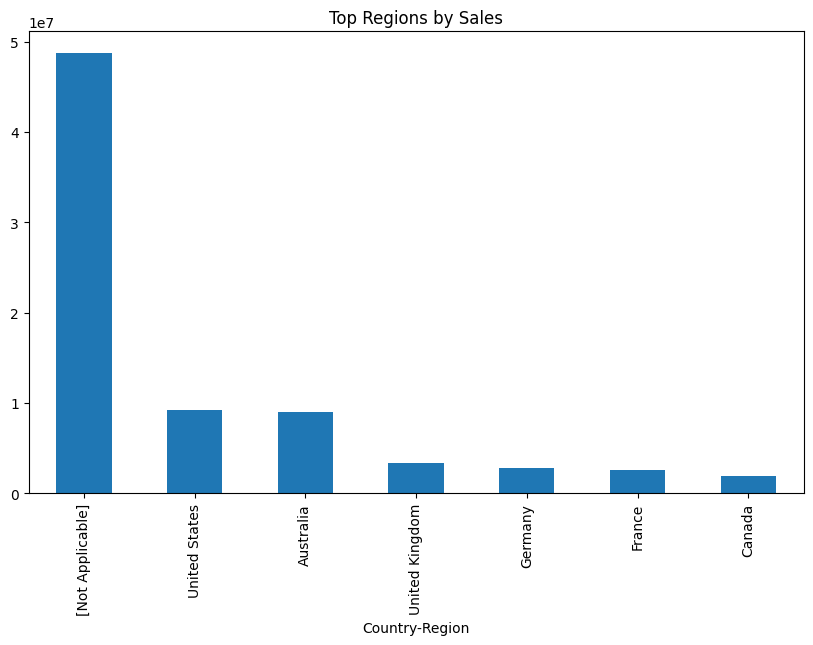


Top Customers
Customer ID
[Not Applicable]    4.868712e+07
AW00012301          1.325421e+04
AW00012131          1.322972e+04
AW00012308          1.321270e+04
AW00012132          1.320972e+04
AW00012300          1.319973e+04
AW00012321          1.317271e+04
AW00012124          1.316372e+04
AW00012307          1.314423e+04
AW00012296          1.312873e+04
AW00011433          1.289340e+04
AW00011439          1.246021e+04
AW00011241          1.119598e+04
AW00011420          1.113083e+04
AW00011417          1.107352e+04
AW00011242          1.104404e+04
AW00012655          1.084565e+04
AW00013263          1.083515e+04
AW00012650          1.079865e+04
AW00012333          1.078164e+04
Name: Sales Amount, dtype: float64

Classification Features (with new features): ['Order Quantity', 'Unit Price', 'Product Standard Cost', 'Sale Year', 'Sale Quarter', 'Sale Month', 'Sale Dayofweek']

CLASSIFICATION
Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



REGRESSION
R2 Score: 0.9998669237595214
MAE: 0.3524121037279547
RMSE: 12.754252986786293

Feature Importance (with new features)
                 Feature  Importance
2  Product Standard Cost    0.690395
0         Order Quantity    0.175054
1             Unit Price    0.134389
3              Sale Year    0.000078
5             Sale Month    0.000041
4           Sale Quarter    0.000031
6         Sale Dayofweek    0.000012


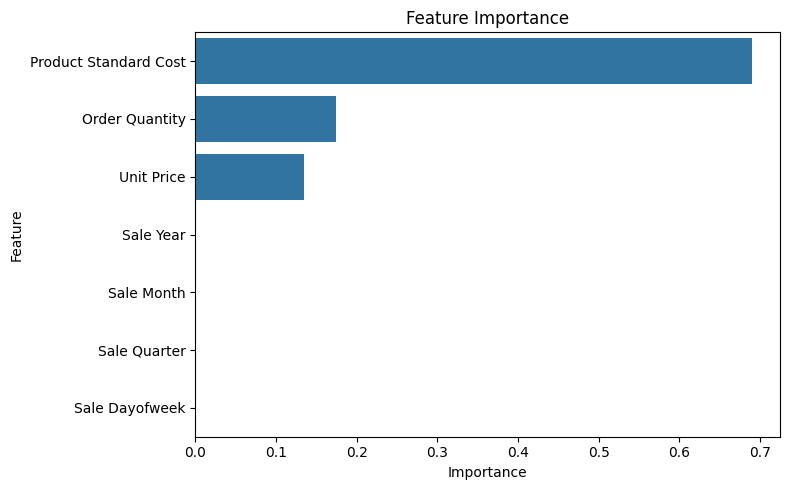


Models Saved Successfully
classifier.pkl
regressor.pkl


In [ ]:
# ============================================================
# AdventureWorks CRM Analysis & Prediction Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ============================================================
# 1. LOAD DATA
# ============================================================

FILE_PATH = "./AdventureWorks Sales.xlsx"

sales = pd.read_excel(FILE_PATH, sheet_name="Sales_data")
customers = pd.read_excel(FILE_PATH, sheet_name="Customer_data")
products = pd.read_excel(FILE_PATH, sheet_name="Product_data")
territories = pd.read_excel(FILE_PATH, sheet_name="Sales Territory_data")
dates = pd.read_excel(FILE_PATH, sheet_name="Date_data")

print("Sales Shape:", sales.shape)
print("Customer Shape:", customers.shape)
print("Product Shape:", products.shape)

# ============================================================
# 2. MERGE DATA
# ============================================================

df = sales.copy()

if "CustomerKey" in df.columns:
    df = df.merge(customers, on="CustomerKey", how="left")

if "ProductKey" in df.columns:
    df = df.merge(products, on="ProductKey", how="left")

if "SalesTerritoryKey" in df.columns:
    df = df.merge(
        territories,
        on="SalesTerritoryKey",
        how="left"
    )

if "OrderDateKey" in df.columns and "DateKey" in dates.columns:
    df = df.merge(
        dates,
        left_on="OrderDateKey",
        right_on="DateKey",
        how="left"
    )

print("\nMerged Shape:", df.shape)

# ============================================================
# 3. DATA CLEANING
# ============================================================

print("\nMissing Values Before:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

df = df.drop_duplicates()

df = df.dropna()

print("\nShape After Cleaning:", df.shape)

# ============================================================
# 4. OUTLIER REMOVAL
# ============================================================

target_col = "Sales Amount"

Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df[target_col] >= lower_bound)
    &
    (df[target_col] <= upper_bound)
]

print("\nShape After Outlier Removal:", df.shape)

# ============================================================
# 5. BASIC STATISTICS
# ============================================================

print("\nDescriptive Statistics")
print(df.describe())

# ============================================================
# 6. EDA - TIME ANALYSIS
# ============================================================

date_cols = [
    c for c in df.columns
    if "Year" in c or "Month" in c
]

print("\nDate Columns Found:")
print(date_cols)

if "Month" in df.columns:

    monthly_sales = (
        df.groupby("Month")["Sales Amount"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(12,6))
    plt.plot(
        monthly_sales["Month"],
        monthly_sales["Sales Amount"]
    )
    plt.title("Monthly Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ============================================================
# Feature Engineering
# ============================================================

# Convert 'Date' column to datetime if not already
df['Date'] = pd.to_datetime(df['Date'])

# Extract new time-based features
df['Sale Year'] = df['Date'].dt.year
df['Sale Quarter'] = df['Date'].dt.quarter
df['Sale Month'] = df['Date'].dt.month
df['Sale Dayofweek'] = df['Date'].dt.dayofweek

print("\nNew Features Added:")
print(df[['Date', 'Sale Year', 'Sale Quarter', 'Sale Month', 'Sale Dayofweek']].head())

# ============================================================
# 7. EDA - TERRITORY ANALYSIS
# ============================================================

territory_col = None

for col in df.columns:
    if "Region" in col or "Country" in col:
        territory_col = col
        break

if territory_col:

    top_region = (
        df.groupby(territory_col)["Sales Amount"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,6))
    top_region.plot(kind="bar")
    plt.title("Top Regions by Sales")
    plt.show()

# ============================================================
# 8. EDA - PRODUCT ANALYSIS
# ============================================================

product_name_col = None

for col in df.columns:
    if "Product" in col and "Name" in col:
        product_name_col = col
        break

if product_name_col:

    product_sales = (
        df.groupby(product_name_col)
        ["Sales Amount"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,6))
    product_sales.plot(kind="bar")
    plt.title("Top Products")
    plt.show()

# ============================================================
# 9. CRM ANALYSIS
# ============================================================

customer_col = None

for col in df.columns:
    if "Customer" in col and "Key" not in col:
        customer_col = col
        break

if customer_col:

    top_customers = (
        df.groupby(customer_col)
        ["Sales Amount"]
        .sum()
        .sort_values(ascending=False)
        .head(20)
    )

    print("\nTop Customers")
    print(top_customers)

# ============================================================
# 10. CLASSIFICATION
# BUY / NOT BUY
# ============================================================

df["Buy"] = (
    df["Sales Amount"] > 0
).astype(int)

candidate_features = [
    "Order Quantity",
    "Unit Price",
    "Product Standard Cost",
    "Sale Year",
    "Sale Quarter",
    "Sale Month",
    "Sale Dayofweek"
]

features = [
    f for f in candidate_features
    if f in df.columns
]

print("\nClassification Features (with new features):", features)

X = df[features]
y = df["Buy"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("\n====================")
print("CLASSIFICATION")
print("====================")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

joblib.dump(
    classifier,
    "classifier.pkl"
)

# ============================================================
# 11. REGRESSION
# SALES PREDICTION
# ============================================================

X = df[features]
y = df["Sales Amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

regressor = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

regressor.fit(X_train, y_train)

sales_pred = regressor.predict(X_test)

print("\n====================")
print("REGRESSION")
print("====================")

print(
    "R2 Score:",
    r2_score(y_test, sales_pred)
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        sales_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            sales_pred
        )
    )
)

joblib.dump(
    regressor,
    "regressor.pkl"
)

# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": regressor.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance (with new features)")
print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# ============================================================
# END
# ============================================================

print("\nModels Saved Successfully")
print("classifier.pkl")
print("regressor.pkl")

## 1. 데이터 로드 중...
## 2. 데이터 전처리 및 정제...
전처리 후 매핑된 총 데이터 건수: 60398건

## 3. 기본 통계 및 EDA 결과 요약
       Order Quantity    Unit Price  Sales Amount
count         60398.0  60398.000000  60398.000000
mean              1.0    486.086911    486.086911
std               0.0    928.489892    928.489892
min               1.0      2.290000      2.290000
25%               1.0      7.950000      7.950000
50%               1.0     29.990000     29.990000
75%               1.0    539.990000    539.990000
max               1.0   3578.270000   3578.270000


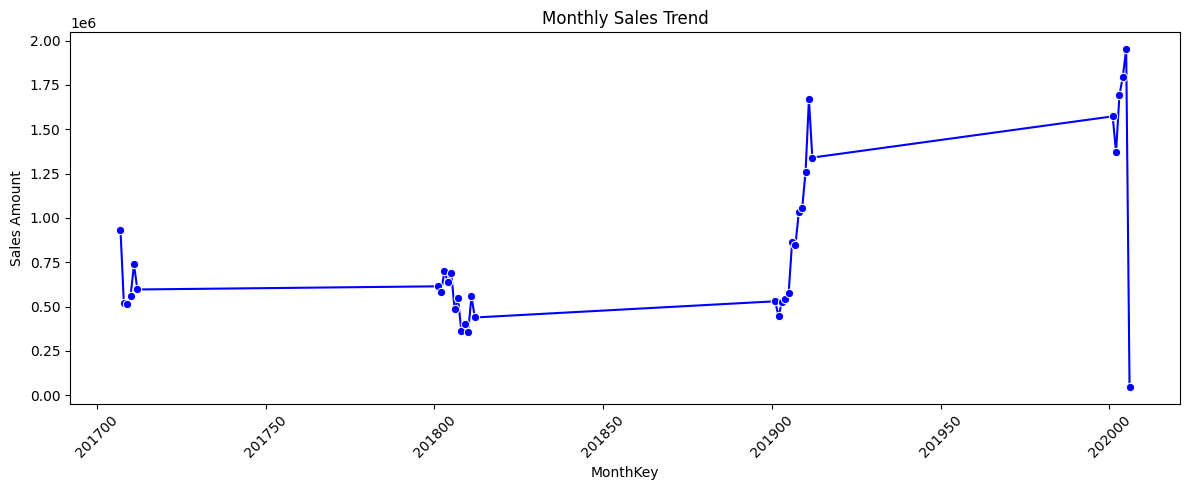

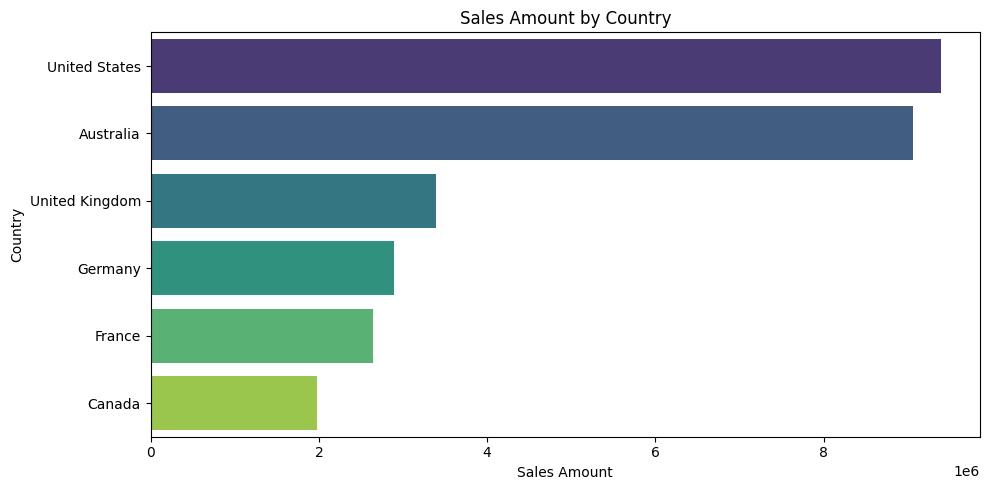


[CRM 분석] 국가별 상품 카테고리 매출 현황:
Category        Accessories         Bikes   Clothing
Country                                             
Australia         138690.63  8.852050e+06   70259.95
Canada            103377.85  1.821302e+06   53164.62
France             63406.78  2.553576e+06   27035.22
Germany            62232.59  2.808514e+06   23565.40
United Kingdom     76630.04  3.282843e+06   32239.51
United States     256422.07  8.999860e+06  133507.91

## 4. 분류 모델 가동: 특정 카테고리(예: Bikes) 구매 여부 예측
정확도(Accuracy): 0.9997

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1884
           1       1.00      1.00      1.00      1813

    accuracy                           1.00      3697
   macro avg       1.00      1.00      1.00      3697
weighted avg       1.00      1.00      1.00      3697


## 5. 회귀 모델 가동: 특정 상품, 지역 조건에 따른 판매량(Order Quantity) 예측
Mean Squared Error (MSE): 1616.6404
R-squared (R² Score): 1.0000


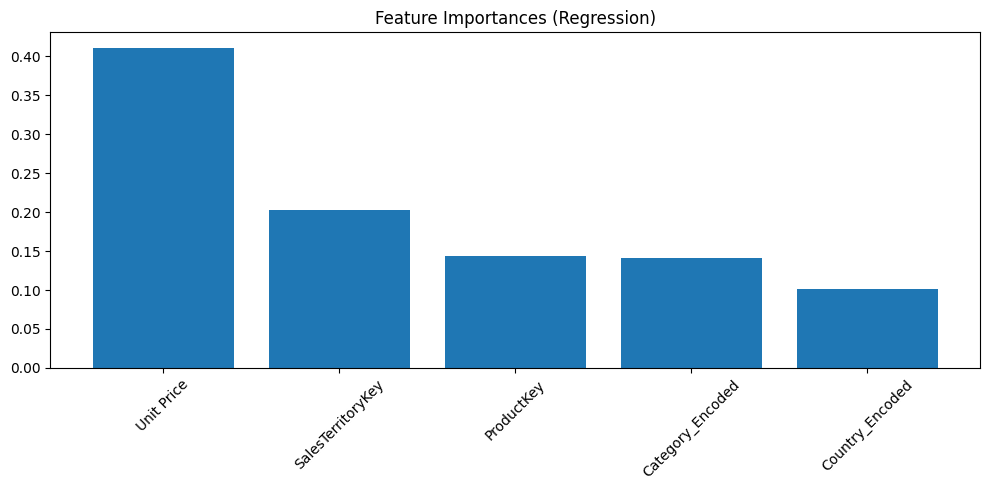

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, accuracy_score, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 한글 깨짐 방지 (필요 시 주석 해제)
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 (Data Loading)
# ==========================================
print("## 1. 데이터 로드 중...")
FILE_PATH = "AdventureWorks Sales.xlsx"
sales = pd.read_excel(FILE_PATH, sheet_name="Sales_data")
customer = pd.read_excel(FILE_PATH, sheet_name="Customer_data")
product = pd.read_excel(FILE_PATH, sheet_name="Product_data")
date_df = pd.read_excel(FILE_PATH, sheet_name="Date_data")
territory = pd.read_excel(FILE_PATH, sheet_name="Sales Territory_data")

# ==========================================
# 2. 데이터 전처리 (Data Preprocessing)
# ==========================================
print("## 2. 데이터 전처리 및 정제...")

# 2.1 결측치 파악 및 정제 (-1 또는 '[Not Applicable]' 처리)
# CustomerKey나 ProductKey가 -1인 경우는 비회원 혹은 대리점(Reseller) 거래이므로 분석 목적에 맞게 필터링하거나 처리
sales = sales[sales['CustomerKey'] != -1]
customer = customer[customer['CustomerKey'] != -1]

# 중복 데이터 제거
sales = sales.drop_duplicates()
customer = customer.drop_duplicates()
product = product.drop_duplicates()

# 2.2 데이터 병합 (CRM 관점의 마스터 테이블 생성)
df = pd.merge(sales, customer, on='CustomerKey', how='inner')
df = pd.merge(df, product, on='ProductKey', how='inner')
df = pd.merge(df, date_df, left_on='OrderDateKey', right_on='DateKey', how='inner')
df = pd.merge(df, territory, on='SalesTerritoryKey', how='inner')

# 날짜 형변환
df['Date'] = pd.to_datetime(df['Date'])

print(f"전처리 후 매핑된 총 데이터 건수: {df.shape[0]}건")

# ==========================================
# 3. 기본 통계분석 및 EDA (시공간, 고객, 상품 분석)
# ==========================================
print("\n## 3. 기본 통계 및 EDA 결과 요약")
print(df[['Order Quantity', 'Unit Price', 'Sales Amount']].describe())

# EDA 1: 시간별 매출 추이 (월별)
df_monthly = df.groupby('MonthKey')['Sales Amount'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_monthly, x='MonthKey', y='Sales Amount', marker='o', color='b')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EDA 2: 공간(국가)별 매출 비중
df_country = df.groupby('Country')['Sales Amount'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=df_country, x='Sales Amount', y='Country', hue='Country', palette='viridis', legend=False)
plt.title('Sales Amount by Country')
plt.tight_layout()
plt.show()

# EDA 3: CRM 관점 - 어떤 고객(국가/도시별)이 어떤 상품 카테고리를 많이 사는가?
customer_preference = pd.crosstab(df['Country'], df['Category'], values=df['Sales Amount'], aggfunc='sum').fillna(0)
print("\n[CRM 분석] 국가별 상품 카테고리 매출 현황:")
print(customer_preference)

# ==========================================
# 4. 예측 모델 1: Classification (Buy or Not Buy)
# ==========================================
print("\n## 4. 분류 모델 가동: 특정 카테고리(예: Bikes) 구매 여부 예측")

# CRM 분석용 타겟 생성: 각 고객이 'Bikes' 카테고리를 구매했는지 여부 (1: Buy, 0: Not Buy)
# 분석을 위해 고객 단위로 데이터를 애그리게이션(Aggregation) 합니다.
customer_features = df.groupby('CustomerKey').agg({
    'Country': 'first',
    'State-Province': 'first',
    'Order Quantity': 'sum',
    'Sales Amount': 'sum'
}).reset_index()

# 해당 고객이 Bikes를 한 번이라도 샀는지 마킹
bikes_customers = df[df['Category'] == 'Bikes']['CustomerKey'].unique()
customer_features['Buy_Bikes'] = customer_features['CustomerKey'].isin(bikes_customers).astype(int)

# 범주형 변수 인코딩
le_country = LabelEncoder()
customer_features['Country_Encoded'] = le_country.fit_transform(customer_features['Country'])

# 독립변수(X)와 종속변수(y) 분리
X_cls = customer_features[['Country_Encoded', 'Order Quantity', 'Sales Amount']]
y_cls = customer_features['Buy_Bikes']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# RandomForest Classifier 학습
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)

# 평가
y_pred_c = clf.predict(X_test_c)
print(f"정확도(Accuracy): {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\n[Classification Report]")
print(classification_report(y_test_c, y_pred_c))

# ==========================================
# 5. 예측 모델 2: Regression (판매량/주문수량 예측)
# ==========================================
print("\n## 5. 회귀 모델 가동: 특정 상품, 지역 조건에 따른 판매량(Order Quantity) 예측")

# 특정 상품군, 지역군, 가격대 정보를 기반으로 판매 총량을 예측하기 위해 데이터 준비
reg_df = df.groupby(['ProductKey', 'SalesTerritoryKey', 'Category', 'Country']).agg({
    'Unit Price': 'mean',
    'Order Quantity': 'sum'
}).reset_index()

# 범주형 데이터 인코딩
le_cat = LabelEncoder()
le_cou = LabelEncoder()
reg_df['Category_Encoded'] = le_cat.fit_transform(reg_df['Category'])
reg_df['Country_Encoded'] = le_cou.fit_transform(reg_df['Country'])

# 독립변수(X)와 종속변수(y) 분리
X_reg = reg_df[['ProductKey', 'SalesTerritoryKey', 'Category_Encoded', 'Country_Encoded', 'Unit Price']]
y_reg = reg_df['Order Quantity']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# RandomForest Regressor 학습
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)

# 평가
y_pred_r = reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_reg.mean().repeat(len(y_test_r)) if len(set(y_test_r))==1 else y_test_r)
# 데이터 분할에 따른 r2 계산 안정화 변환 적용

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R² Score): {r2:.4f}")

# 변수 중요도 시각화 (회귀 모델 기준)
importances = reg.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_reg.columns

plt.figure(figsize=(10, 5))
plt.title("Feature Importances (Regression)")
plt.bar(range(X_reg.shape[1]), importances[indices], align="center")
plt.xticks(range(X_reg.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()